In [ ]:
from google.colab import files
uploaded = files.upload()

Saving train-2 (2).csv to train-2 (2) (1).csv


In [ ]:
df = pd.read_csv('train-2 (2).csv')
df.head()

,id,Name,Event_Number,Event_Length_minutes,Genre,Host_Popularity_percentage,Event_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Sponsers,Event_Sentiment,Watch_Time_minutes
0,0,Mystery Matters,Episode 98,NaN,True Crime,74.81,Thursday,Night,NaN,0.0,Positive,31.41998
1,1,Joke Junction,Episode 26,119.80,Comedy,66.95,Saturday,Afternoon,75.95,2.0,Negative,88.01241
2,2,Study Sessions,Episode 16,73.90,Education,69.97,Tuesday,Evening,8.97,0.0,Negative,44.92531
3,3,Digital Digest,Episode 45,67.17,Technology,57.22,Monday,Morning,78.70,2.0,Positive,46.27824
4,4,Mind & Body,Episode 86,110.51,Health,80.07,Monday,Afternoon,58.68,3.0,Neutral,75.61031


In [ ]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750000 entries, 0 to 749999
Data columns (total 12 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           750000 non-null  int64  
 1   Name                         750000 non-null  object 
 2   Event_Number                 750000 non-null  object 
 3   Event_Length_minutes         662907 non-null  float64
 4   Genre                        750000 non-null  object 
 5   Host_Popularity_percentage   750000 non-null  float64
 6   Event_Day                    750000 non-null  object 
 7   Publication_Time             750000 non-null  object 
 8   Guest_Popularity_percentage  603970 non-null  float64
 9   Number_of_Sponsers           749999 non-null  float64
 10  Event_Sentiment              750000 non-null  object 
 11  Watch_Time_minutes           750000 non-null  float64
dtypes: float64(5), int64(1), object(6)
memory usage: 68.7+ MB


# Data Loading and Importing Libraries


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import shapiro
from scipy.stats import pearsonr
from scipy.stats import norm
import numpy as np
import math
import itertools
df = pd.read_csv('train-2 (2).csv')

### Section 1 – General Statistics of the Dataset


In [ ]:
df.describe()

,id,Event_Length_minutes,Host_Popularity_percentage,Guest_Popularity_percentage,Number_of_Sponsers,Watch_Time_minutes
count,750000.000000,662907.000000,750000.000000,603970.000000,749999.000000,750000.000000
mean,374999.500000,64.504738,59.859901,52.236449,1.348855,45.437406
std,216506.495284,32.969603,22.873098,28.451241,1.151130,27.138306
min,0.000000,0.000000,1.300000,0.000000,0.000000,0.000000
25%,187499.750000,35.730000,39.410000,28.380000,0.000000,23.178350
50%,374999.500000,63.840000,60.050000,53.580000,1.000000,43.379460
75%,562499.250000,94.070000,79.530000,76.600000,2.000000,64.811580
max,749999.000000,325.240000,119.460000,119.910000,103.910000,119.970000


### Summary

In the first stage, we performed an initial exploration of the dataset.
We examined the size of the dataset using `df.shape` and found that it contains 750,000 observations and 12 variables.
Next, we used `df.info()` to understand the types of variables and identify whether there are missing values.
Finally, we used `df.describe()` to obtain general statistics for the numerical variables, such as mean, standard deviation, minimum, maximum, and quartiles.
This step helps us better understand the structure of the data before continuing with further analysis.

Section 2 – Counting Categorical and Numerical Variables

In [ ]:
categorical_vars = df.select_dtypes(include=['object']).columns
numerical_vars = df.select_dtypes(include=['int64', 'float64']).columns

print("Number of categorical variables:", len(categorical_vars))
print("Number of numerical variables:", len(numerical_vars))

Number of categorical variables: 6
Number of numerical variables: 6


In [ ]:
print("Categorical variables:")
print(categorical_vars)

print("\nNumerical variables:")
print(numerical_vars)

Categorical variables:
Index(['Name', 'Event_Number', 'Genre', 'Event_Day', 'Publication_Time',
       'Event_Sentiment'],
      dtype='object')

Numerical variables:
Index(['id', 'Event_Length_minutes', 'Host_Popularity_percentage',
       'Guest_Popularity_percentage', 'Number_of_Sponsers',
       'Watch_Time_minutes'],
      dtype='object')


### Summary

In this section we identified the categorical and numerical variables in the dataset.
The dataset contains several categorical variables such as Genre, Event_Day, Publication_Time and Event_Sentiment,
as well as numerical variables such as Event_Length_minutes, Host_Popularity_percentage, Guest_Popularity_percentage and Watch_Time_minutes.
This classification helps us determine which analysis methods are appropriate for each type of variable.

Section 3 – Description of the Categorical Variables

Variable: Name
Name
Tech Talks             22847
Sports Weekly          20053
Funny Folks            19635
Tech Trends            19549
Fitness First          19488
Business Insights      19480
Style Guide            19364
Game Day               19272
Melody Mix             18889
Criminal Minds         17735
Finance Focus          17628
Detective Diaries      17452
Crime Chronicles       17374
Athlete's Arena        17327
Fashion Forward        17280
Tune Time              17254
Business Briefs        17012
Lifestyle Lounge       16661
True Crime Stories     16373
Sports Central         16191
Digital Digest         16171
Humor Hub              16144
Mystery Matters        16002
Comedy Corner          15927
Joke Junction          15074
Wellness Wave          15009
Sport Spot             14778
Gadget Geek            14770
Home & Living          14686
Laugh Line             14673
Life Lessons           14464
World Watch            14043
Sound Waves            13928
Global News            

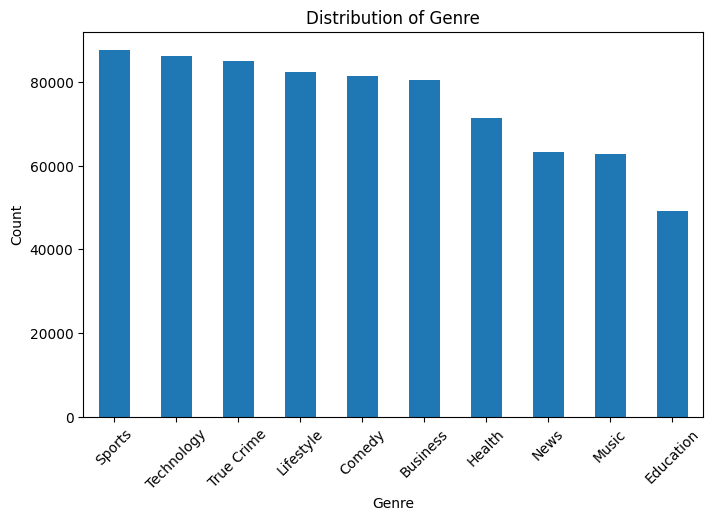

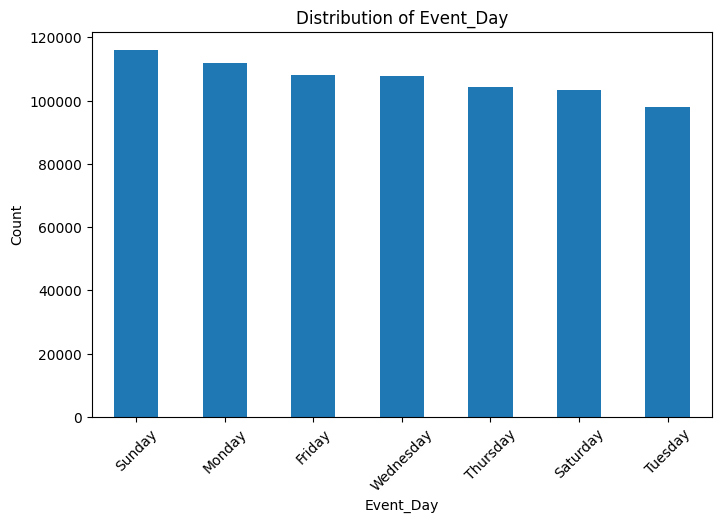

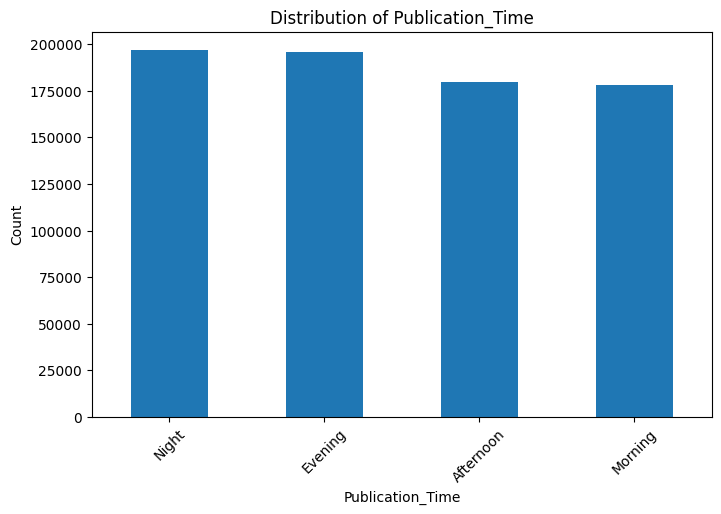

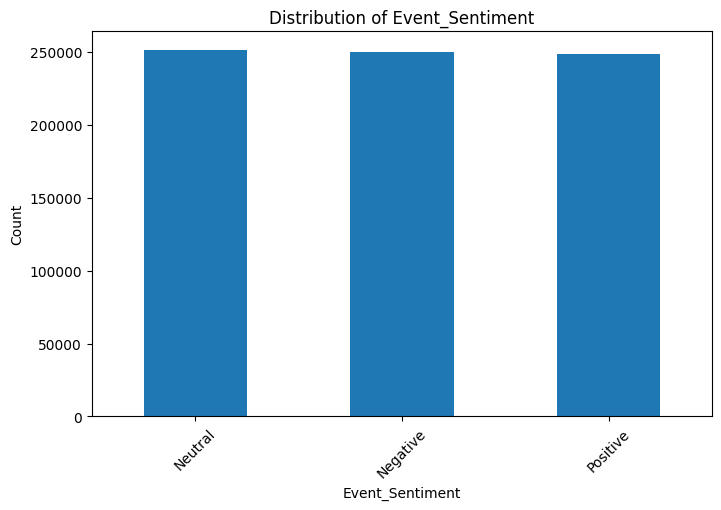

In [ ]:
for col in categorical_vars:
    print("Variable:", col)
    print(df[col].value_counts())
    print("\n")


categorical_plot_vars = ['Genre', 'Event_Day', 'Publication_Time', 'Event_Sentiment']

for col in categorical_plot_vars:
    plt.figure(figsize=(8,5))
    df[col].value_counts().plot(kind='bar')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.show()

### Graph Analysis

The bar charts above illustrate the distribution of several categorical variables in the dataset.
We can observe how the events are distributed across different genres, days of the week, publication times, and sentiment categories.

The results show that some categories appear more frequently than others.
Overall, the distributions appear relatively balanced across most categories.

Section 4 – Description of the Numerical Variables

Variable: id
count    750000.000000
mean     374999.500000
std      216506.495284
min           0.000000
25%      187499.750000
50%      374999.500000
75%      562499.250000
max      749999.000000
Name: id, dtype: float64


Variable: Event_Length_minutes
count    662907.000000
mean         64.504738
std          32.969603
min           0.000000
25%          35.730000
50%          63.840000
75%          94.070000
max         325.240000
Name: Event_Length_minutes, dtype: float64


Variable: Host_Popularity_percentage
count    750000.000000
mean         59.859901
std          22.873098
min           1.300000
25%          39.410000
50%          60.050000
75%          79.530000
max         119.460000
Name: Host_Popularity_percentage, dtype: float64


Variable: Guest_Popularity_percentage
count    603970.000000
mean         52.236449
std          28.451241
min           0.000000
25%          28.380000
50%          53.580000
75%          76.600000
max         119.910000
Name: Guest_Popularity

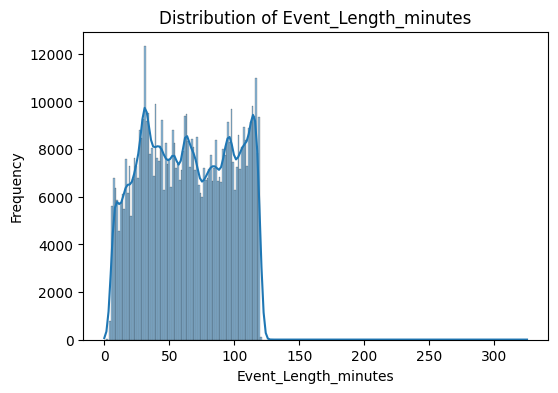

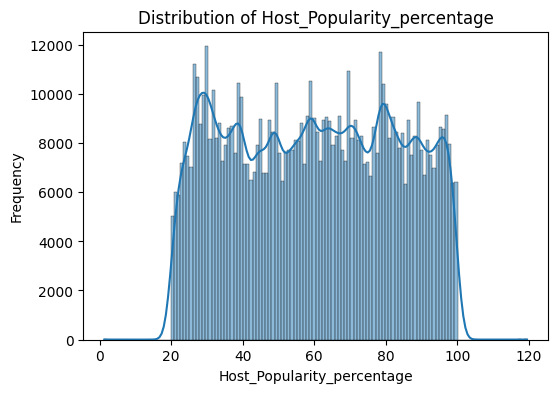

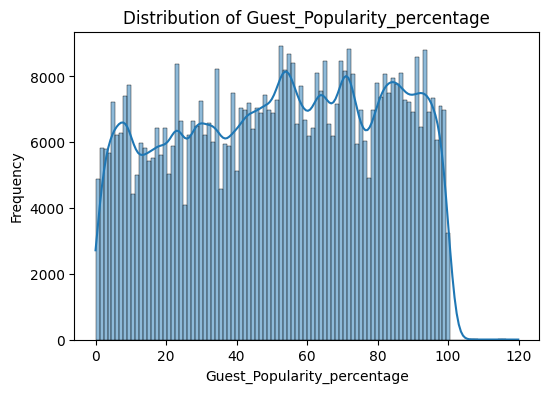

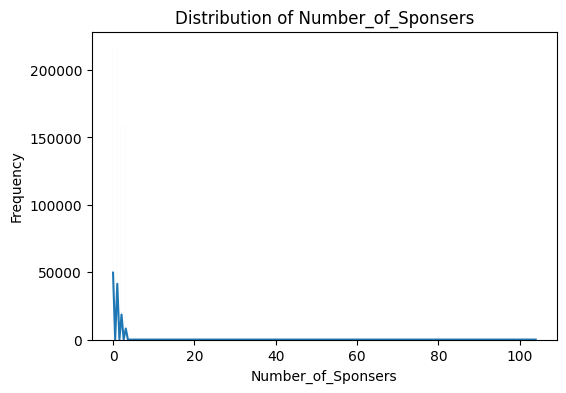

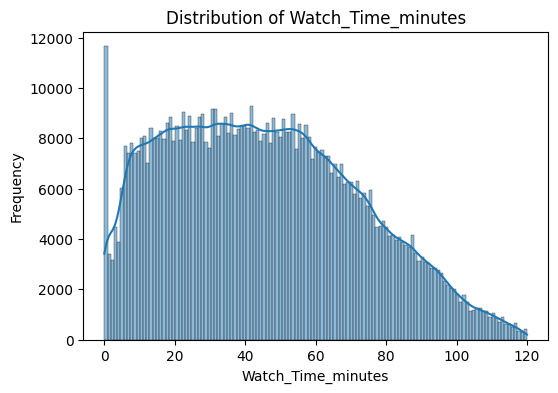

In [ ]:
for col in numerical_vars:
    print("Variable:", col)
    print(df[col].describe())
    print("\n")
numerical_plot_vars = [col for col in numerical_vars if col != 'id']

for col in numerical_plot_vars:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

### Summary

In this section we examined the numerical variables using descriptive statistics.
The results show that the average event length is about 64.5 minutes, while the average watch time is approximately 45.4 minutes.
The host popularity percentage has an average of about 59.9%, while guest popularity averages around 52.2%.

We can also observe that some variables contain missing values. For example, Event_Length_minutes and Guest_Popularity_percentage have fewer observations than the total number of rows in the dataset.
Additionally, the Number_of_Sponsers variable shows a very high maximum value compared to its mean, which may indicate the presence of outliers.

These statistics help us understand the range and distribution of the numerical variables before continuing with further analysis.




### Graph Analysis

The histograms above show the distribution of the numerical variables in the dataset.
These visualizations help us understand how the values are spread across different ranges.

From the graphs we can observe that some variables have a wide range of values, while others are more concentrated around their average.
For example, variables such as Event_Length_minutes and Watch_Time_minutes show variability in their distributions, while other variables may appear more concentrated.

Visualizing the distributions helps identify patterns, skewness, and potential extreme values in the dataset.

Section 5 – Identifying Missing Values and the Variables in Which They Appear

In [ ]:
df.isnull().sum()

,0
id,0
Name,0
Event_Number,0
Event_Length_minutes,87093
Genre,0
Host_Popularity_percentage,0
Event_Day,0
Publication_Time,0
Guest_Popularity_percentage,146030
Number_of_Sponsers,1


### Summary

In this section we identified missing values in the dataset using the `isnull().sum()` function.
The results show that most variables do not contain missing values. However, several variables do include missing data.

Specifically, the variable `Event_Length_minutes` contains 87,093 missing values, while `Guest_Popularity_percentage` contains 146,030 missing values.
In addition, the variable `Number_of_Sponsers` contains only one missing value.

Identifying these missing values is an important step in the analysis process, as it helps determine how the data should be cleaned or handled in later stages of the analysis.

### Summary

In this section we identified missing values in the dataset using the `isnull().sum()` function.
The results show that most variables do not contain missing values. However, several variables do include missing data.

Specifically, the variable `Event_Length_minutes` contains 87,093 missing values, while `Guest_Popularity_percentage` contains 146,030 missing values.
In addition, the variable `Number_of_Sponsers` contains only one missing value.

Identifying these missing values is an important step in the analysis process, as it helps determine how the data should be cleaned or handled in later stages of the analysis.

Section 6 – Handling Missing Values

In [ ]:
df.isnull().sum()
df['Event_Length_minutes'] = df['Event_Length_minutes'].fillna(df['Event_Length_minutes'].median())
df['Guest_Popularity_percentage'] = df['Guest_Popularity_percentage'].fillna(df['Guest_Popularity_percentage'].median())
df['Number_of_Sponsers'] = df['Number_of_Sponsers'].fillna(df['Number_of_Sponsers'].median())

In [ ]:
df.isnull().sum()

,0
id,0
Name,0
Event_Number,0
Event_Length_minutes,0
Genre,0
Host_Popularity_percentage,0
Event_Day,0
Publication_Time,0
Guest_Popularity_percentage,0
Number_of_Sponsers,0


### Summary

In this section we handled the missing values that were previously identified in the dataset.
The analysis showed that missing values appeared in three variables: `Event_Length_minutes`, `Guest_Popularity_percentage`, and `Number_of_Sponsers`.

To address this issue, we replaced the missing values using the median of each variable.
The median was chosen as the replacement method because it is more robust to extreme values and outliers compared to the mean, making it a suitable choice for numerical data.

Handling missing values is an important step in the data preprocessing stage, as incomplete data can negatively affect statistical analysis and model performance.
After replacing the missing values, we verified the dataset again using `isnull().sum()` and confirmed that all variables now contain zero missing values.

This step ensures that the dataset is complete and ready for further analysis in the next stages of the project.

Section 7 – Identifying and Handling Outliers

In [ ]:
for col in numerical_vars:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print("Variable:", col)
    print("Number of outliers:", len(outliers))
    print("\n")

Variable: id
Number of outliers: 0


Variable: Event_Length_minutes
Number of outliers: 1


Variable: Host_Popularity_percentage
Number of outliers: 0


Variable: Guest_Popularity_percentage
Number of outliers: 0


Variable: Number_of_Sponsers
Number of outliers: 9


Variable: Watch_Time_minutes
Number of outliers: 0




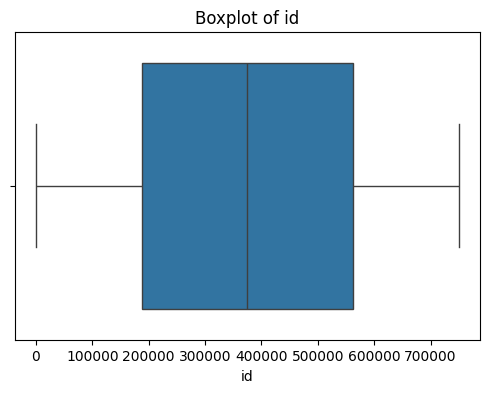

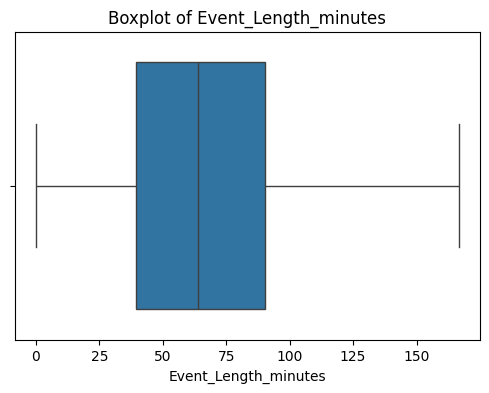

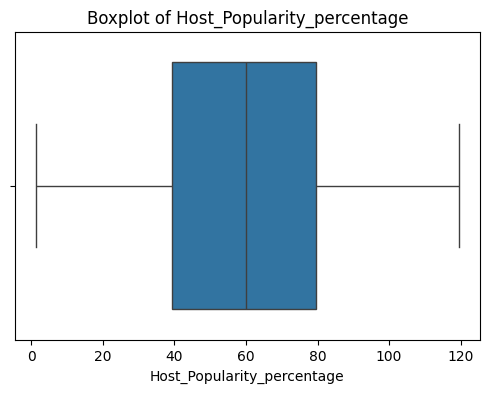

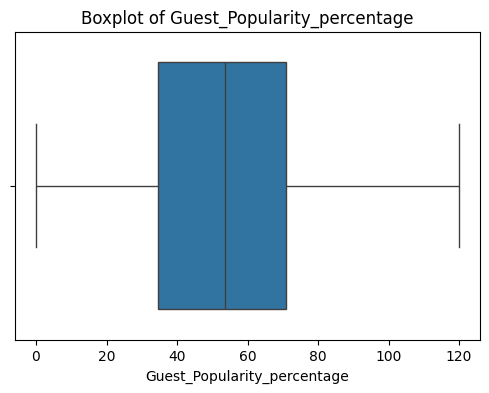

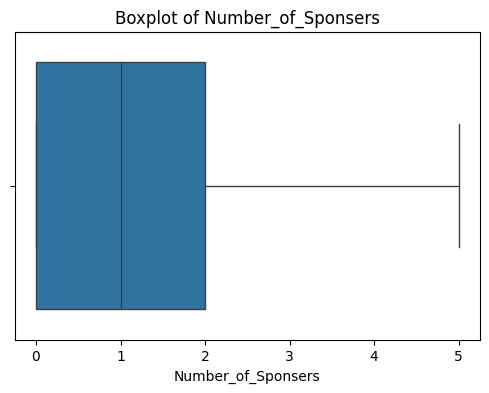

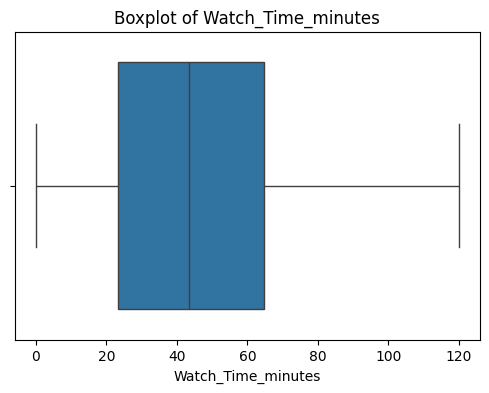

In [ ]:
for col in numerical_vars:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower_bound, upper_bound)
for col in numerical_vars:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

### Summary

In this section we identified and handled potential outliers in the numerical variables of the dataset.
Outliers were detected using the Interquartile Range (IQR) method, which identifies values that fall significantly outside the typical range of the data.

For each numerical variable, we calculated the first quartile (Q1), the third quartile (Q3), and the IQR.
Values that were lower than Q1 − 1.5×IQR or higher than Q3 + 1.5×IQR were considered potential outliers.

To reduce the impact of extreme values on the analysis, we applied a capping approach.
In this process, values that were below the lower bound were replaced with the lower bound, and values that exceeded the upper bound were replaced with the upper bound.

Handling outliers is an important step in data preprocessing, as extreme values can distort statistical measures and negatively influence further analysis.

Section 8 – Normalization of Numerical Values

In [ ]:
scaler = MinMaxScaler()

numerical_scale_vars = [col for col in numerical_vars if col != 'id']

df[numerical_scale_vars] = scaler.fit_transform(df[numerical_scale_vars])

In [ ]:
df[numerical_scale_vars].describe()

,Event_Length_minutes,Host_Popularity_percentage,Guest_Popularity_percentage,Number_of_Sponsers,Watch_Time_minutes
count,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000
mean,0.386614,0.495598,0.437812,0.269586,0.378740
std,0.185999,0.193577,0.212969,0.222206,0.226209
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.236551,0.322529,0.288133,0.000000,0.193201
50%,0.383090,0.497207,0.446835,0.200000,0.361586
75%,0.541930,0.662068,0.592444,0.400000,0.540232
max,1.000000,1.000000,1.000000,1.000000,1.000000


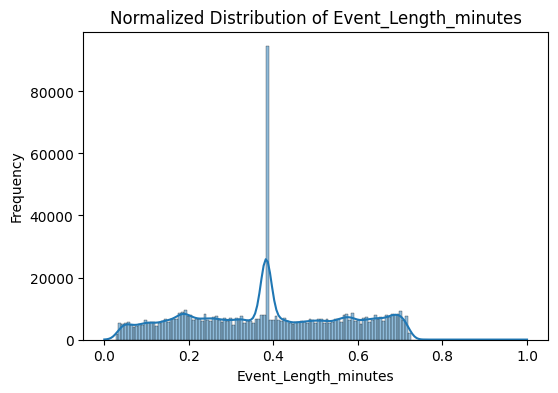

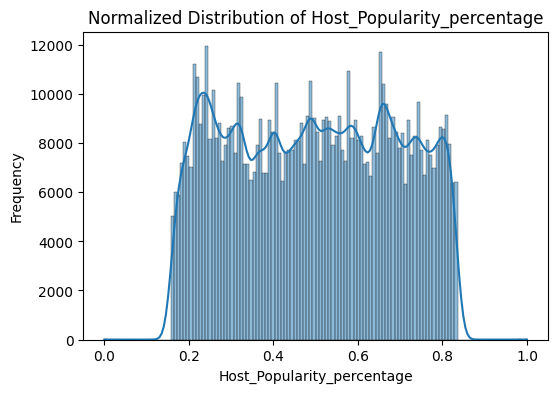

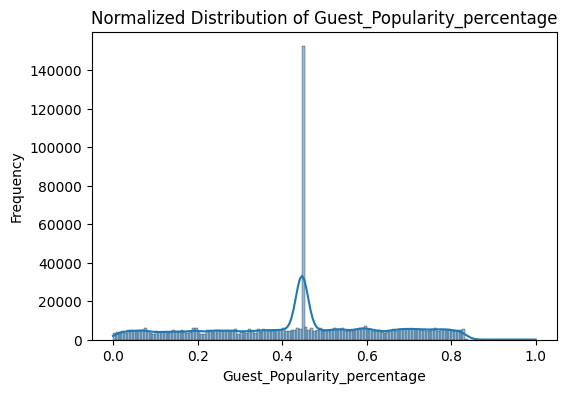

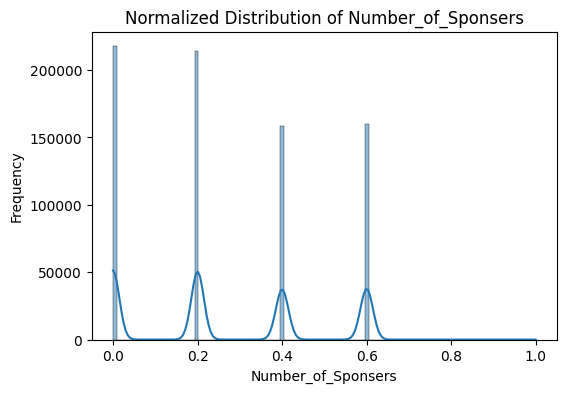

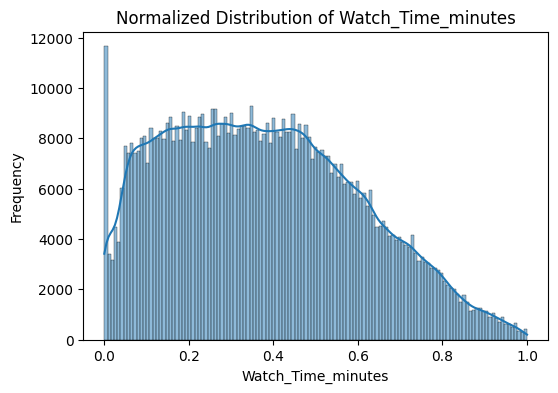

In [ ]:
for col in numerical_scale_vars:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Normalized Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

### Summary
In this section we normalized the numerical variables in the dataset using the Min-Max scaling method.
Normalization transforms numerical values so that they fall within a common range between 0 and 1.
This step helps ensure that variables with larger ranges do not dominate the analysis and allows for fair comparison between variables.

The normalization process was performed using the MinMaxScaler from the sklearn library.
All numerical variables were included in the scaling process except the `id` variable, since it only serves as an identifier and does not contain meaningful analytical information.
After applying the transformation, we verified the results using descriptive statistics to confirm that the values of the variables were successfully scaled to the range between 0 and 1.

### Graph Analysis
The histograms above display the distribution of the normalized numerical variables.
These graphs help visualize how the data is distributed after scaling.
Although the scale of the values has changed, the general shape of the distributions remains similar to the original data.
This indicates that normalization standardizes the scale of the variables while preserving the overall structure of the dataset.

# Section 9 – Correlation Between Variables with Respect to Watch_Time_minutes

In [ ]:
correlation_matrix = df[numerical_scale_vars].corr()
correlation_matrix

,Event_Length_minutes,Host_Popularity_percentage,Guest_Popularity_percentage,Number_of_Sponsers,Watch_Time_minutes
Event_Length_minutes,1.000000,0.022194,-0.008326,-0.054788,0.866251
Host_Popularity_percentage,0.022194,1.000000,0.020416,-0.017876,0.050870
Guest_Popularity_percentage,-0.008326,0.020416,1.000000,0.008829,-0.014446
Number_of_Sponsers,-0.054788,-0.017876,0.008829,1.000000,-0.124132
Watch_Time_minutes,0.866251,0.050870,-0.014446,-0.124132,1.000000


In [ ]:
correlation_with_watch = correlation_matrix['Watch_Time_minutes'].sort_values(ascending=False)
correlation_with_watch

,Watch_Time_minutes
Watch_Time_minutes,1.000000
Event_Length_minutes,0.866251
Host_Popularity_percentage,0.050870
Guest_Popularity_percentage,-0.014446
Number_of_Sponsers,-0.124132


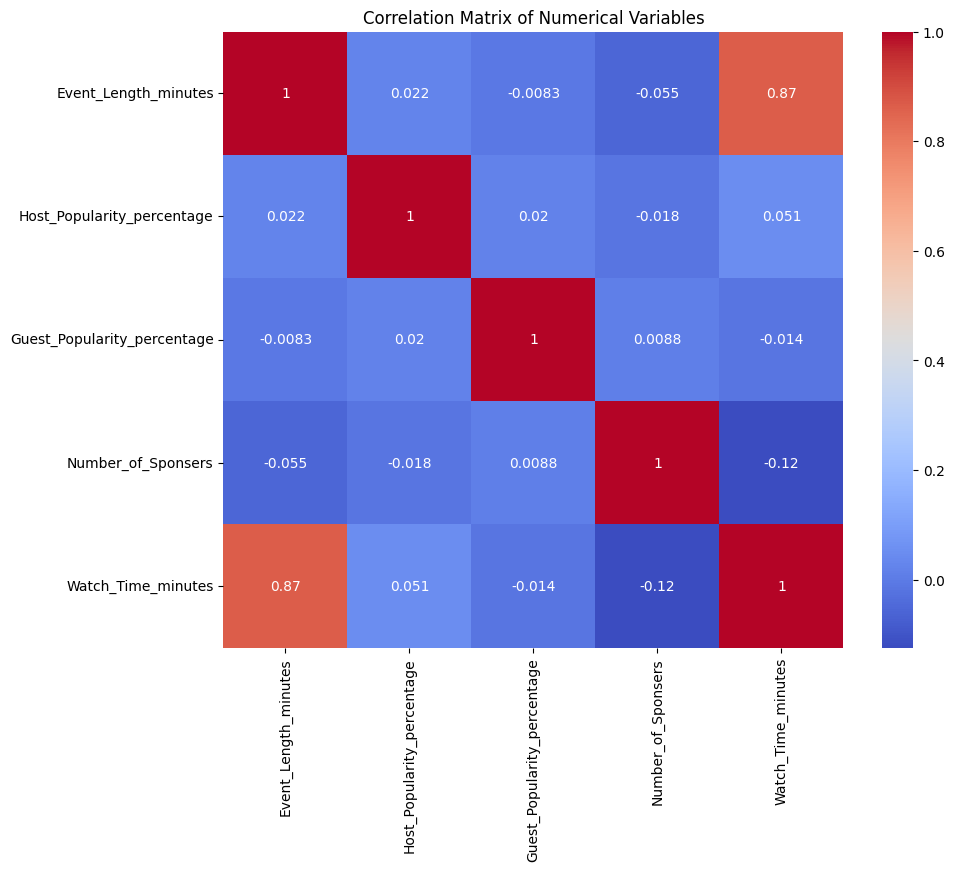

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix of Numerical Variables")
plt.show()

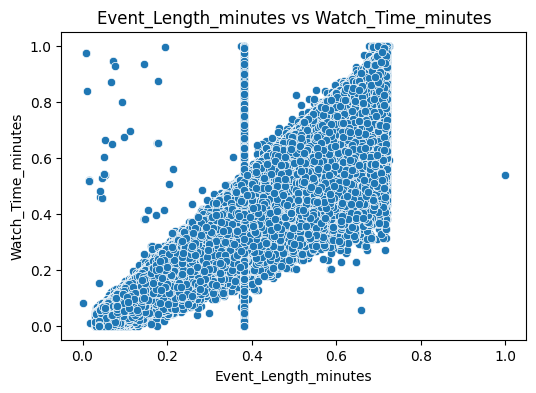

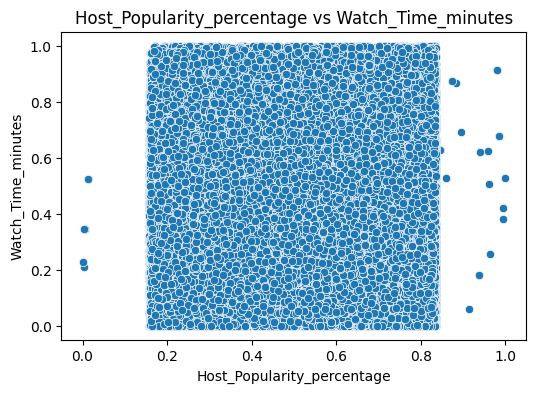

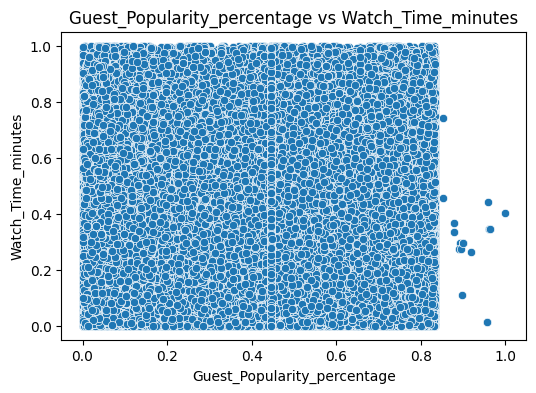

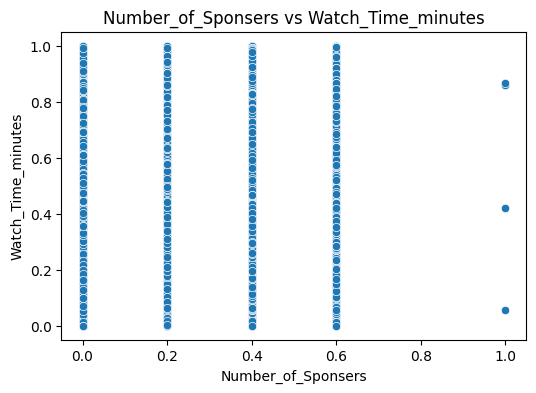

In [ ]:
for col in numerical_scale_vars:
    if col != 'Watch_Time_minutes':
        plt.figure(figsize=(6,4))
        sns.scatterplot(x=df[col], y=df['Watch_Time_minutes'])
        plt.title(f'{col} vs Watch_Time_minutes')
        plt.xlabel(col)
        plt.ylabel('Watch_Time_minutes')
        plt.show()

### Summary
In this section we analyzed the relationships between the numerical variables in the dataset, with a particular focus on the variable `Watch_Time_minutes`, which represents the watch time of the events.
Understanding the relationships between variables is important because it can help identify which factors may influence or be associated with the watch time.

### Explanation
To examine the relationships between the variables, we calculated the Pearson correlation coefficient for all numerical variables in the dataset.
The Pearson correlation coefficient measures the strength and direction of the linear relationship between two variables.
Its values range from -1 to 1, where values close to 1 indicate a strong positive correlation, values close to -1 indicate a strong negative correlation, and values close to 0 indicate little or no linear relationship.

We specifically examined the correlations with `Watch_Time_minutes` in order to understand which variables may be more strongly associated with watch time.
Identifying these relationships can provide insights into potential factors that influence audience engagement.

### Graph Analysis
To complement the numerical analysis, we visualized the correlations using a heatmap of the correlation matrix.
The heatmap provides a clear visual representation of the relationships between all numerical variables, allowing us to quickly identify stronger or weaker correlations.

In addition, scatter plots were used to visualize the relationship between each numerical variable and `Watch_Time_minutes`.
These plots help illustrate how the values of different variables relate to watch time and allow us to visually identify patterns, trends, or potential relationships between the variables.

Overall, combining both numerical and visual analysis provides a better understanding of the relationships within the dataset and helps highlight variables that may be relevant for further analysis.

# Section 10 – Visualization of Variable Distributions Individually and Together

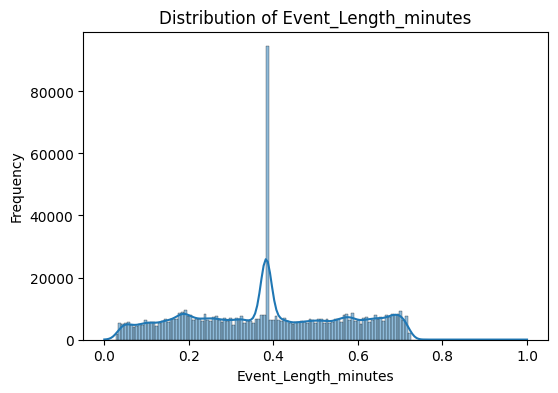

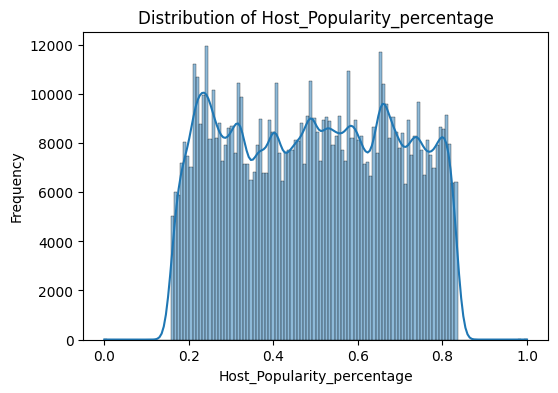

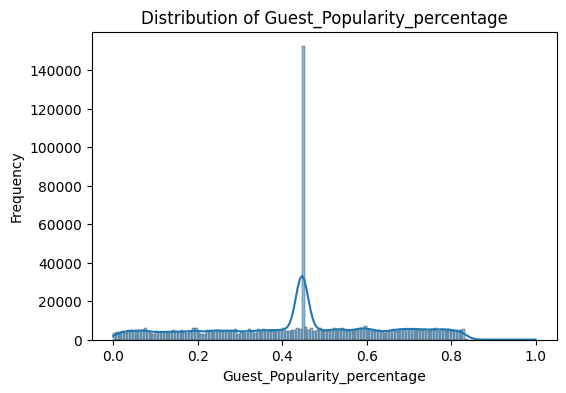

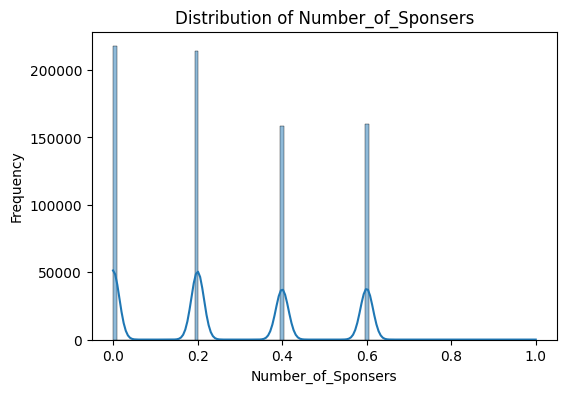

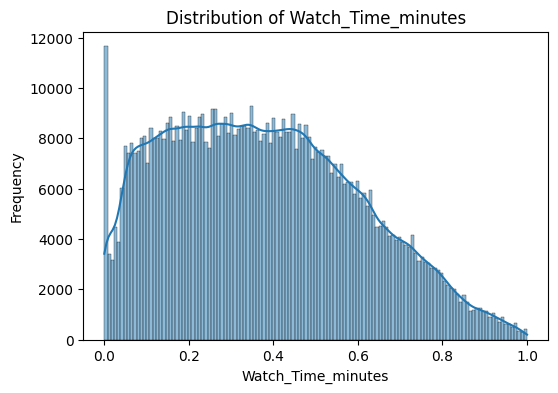

In [ ]:
for col in numerical_scale_vars:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

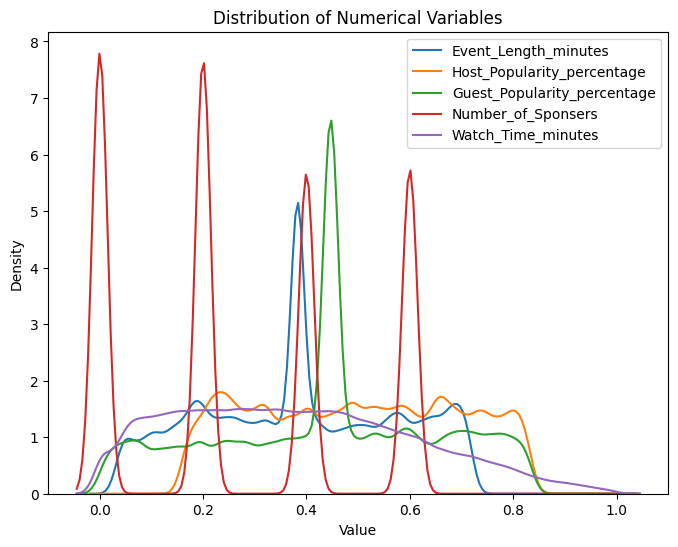

In [ ]:
plt.figure(figsize=(8,6))

for col in numerical_scale_vars:
    sns.kdeplot(df[col], label=col)

plt.title("Distribution of Numerical Variables")
plt.xlabel("Value")
plt.ylabel("Density")
plt.legend()
plt.show()

### Summary
In this section we visualized the distributions of the numerical variables both individually and together.
Visualizing the distributions helps us better understand how the values of each variable are spread across the dataset.

### Explanation
Histograms were used to examine the distribution of each numerical variable separately.
These graphs allow us to observe patterns such as concentration of values, spread, and potential skewness in the data.

In addition, a combined density plot was created to visualize multiple variables together.
This allows for easier comparison of the overall distribution patterns between the different variables.

### Graph Analysis
The individual histograms provide insight into how each variable is distributed across its range of values.
The combined density plot helps highlight similarities or differences between the distributions of the numerical variables.

Overall, these visualizations provide a clearer understanding of the structure and variability of the dataset.

# Section 11 – Visualization of Variables with Respect to Watch_Time_minutes

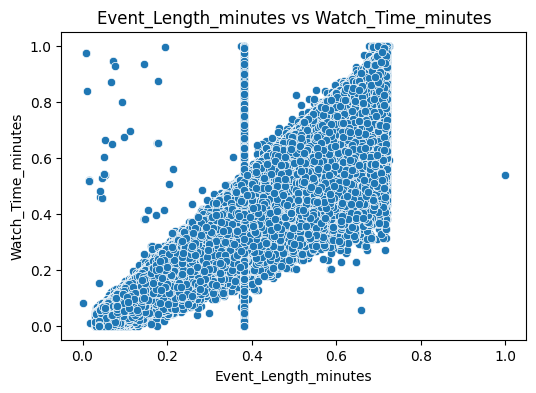

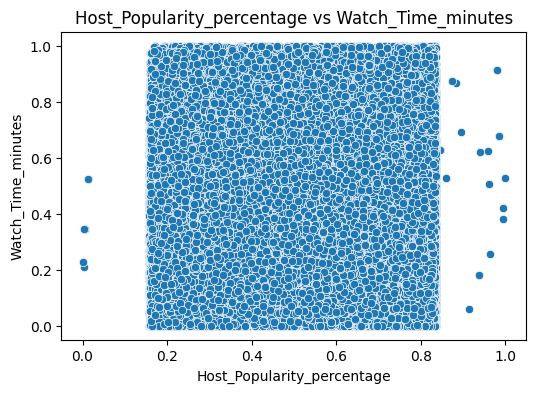

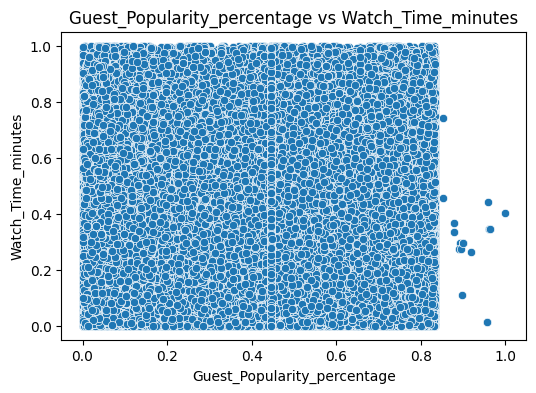

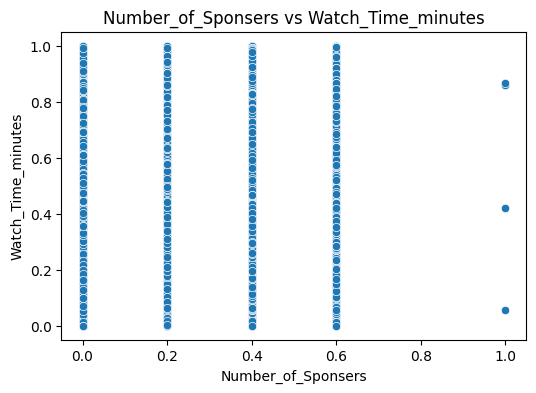

In [ ]:
for col in numerical_scale_vars:
    if col != 'Watch_Time_minutes':
        plt.figure(figsize=(6,4))
        sns.scatterplot(x=df[col], y=df['Watch_Time_minutes'])
        plt.title(f'{col} vs Watch_Time_minutes')
        plt.xlabel(col)
        plt.ylabel('Watch_Time_minutes')
        plt.show()

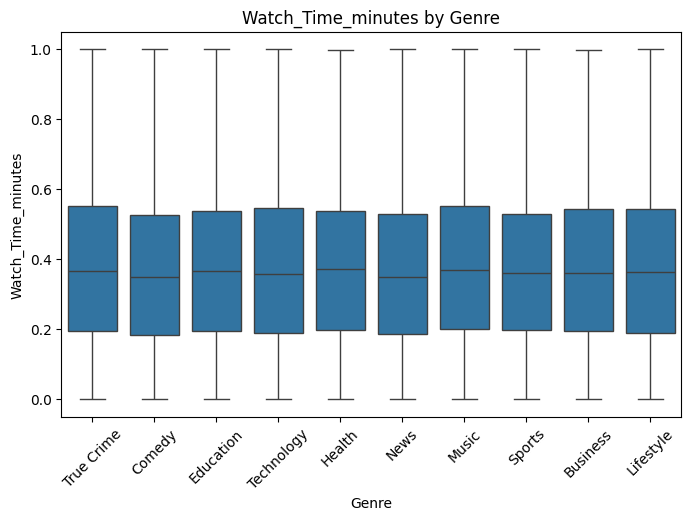

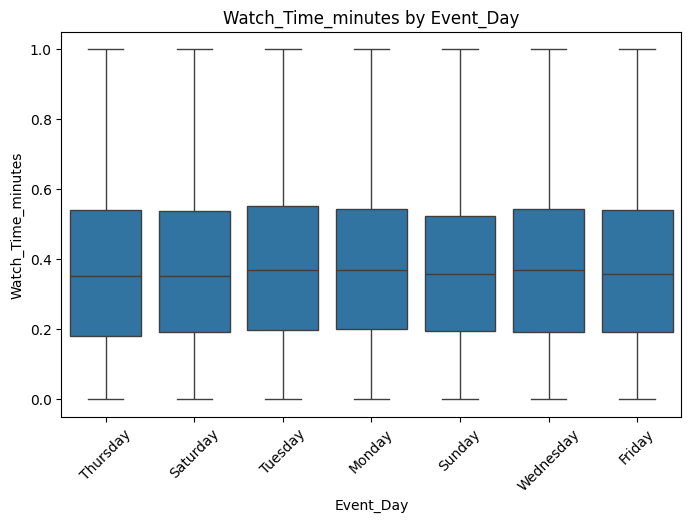

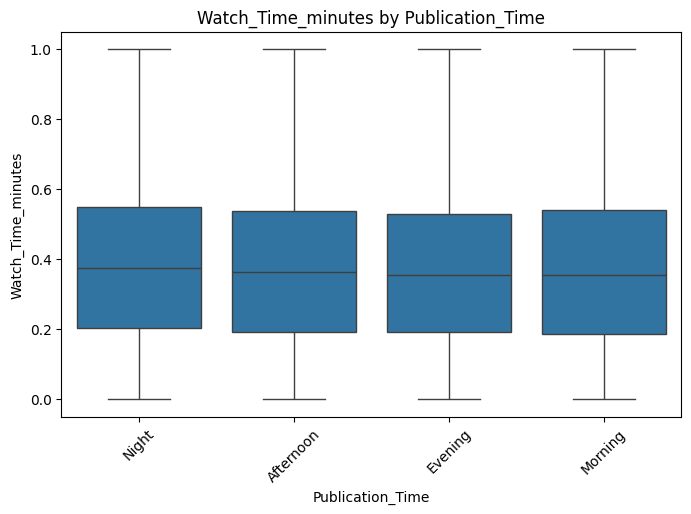

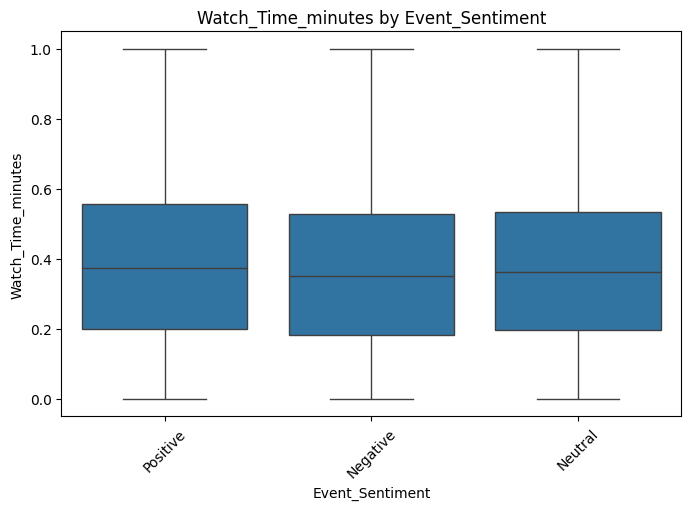

In [ ]:
categorical_plot_vars = ['Genre', 'Event_Day', 'Publication_Time', 'Event_Sentiment']

for col in categorical_plot_vars:
    plt.figure(figsize=(8,5))
    sns.boxplot(x=df[col], y=df['Watch_Time_minutes'])
    plt.title(f'Watch_Time_minutes by {col}')
    plt.xlabel(col)
    plt.ylabel('Watch_Time_minutes')
    plt.xticks(rotation=45)
    plt.show()

### Summary
In this section we explored how different variables relate to the watch time of events, represented by the variable `Watch_Time_minutes`.

### Explanation
To better understand these relationships, we visualized the connection between `Watch_Time_minutes` and other variables in the dataset.
Scatter plots were used for numerical variables to observe possible relationships between continuous values.
For categorical variables, boxplots were used to compare the distribution of watch time across different categories.

### Graph Analysis
The scatter plots illustrate the relationship between watch time and the numerical variables in the dataset.
These graphs help reveal whether changes in variables such as event length or popularity percentages are associated with changes in watch time.

The boxplots show how watch time varies across different categories such as genre, event day, publication time, and sentiment.
These visualizations help identify whether certain categories tend to have higher or lower watch time compared to others.

Overall, these visualizations provide insight into which variables may be associated with watch time and help highlight patterns that may be useful for further analysis.

# Final Conclusion
In this project we performed an exploratory data analysis of the dataset in order to better understand the structure and relationships between the variables.

The analysis began with an initial exploration of the dataset, including examining the size of the data, the types of variables, and the general statistical properties of the numerical variables. We then identified the categorical and numerical variables and analyzed their distributions using both numerical summaries and visualizations.

Next, we examined the dataset for missing values and handled them by replacing the missing values in numerical variables with their median values. This ensured that the dataset was complete and suitable for further analysis.

We also identified and handled potential outliers using the interquartile range (IQR) method in order to reduce the influence of extreme values on the analysis. After that, the numerical variables were normalized using the Min-Max scaling method so that all variables would be on a comparable scale.

In addition, we analyzed the relationships between variables by calculating correlation coefficients and visualizing them using heatmaps and scatter plots. Special attention was given to the variable `Watch_Time_minutes`, which represents the watch time of events.

Finally, we visualized the distributions of the variables both individually and together, as well as their relationships with watch time. These visualizations provided further insight into the patterns and structure of the dataset.

Overall, the analysis helped reveal important characteristics of the dataset and provided a clearer understanding of the factors that may influence watch time.